In [13]:
from google.colab import files
uploaded = files.upload()
!unzip -o src.zip

import sys
import os
sys.path.insert(0, '/content')

Saving src.zip to src (1).zip
Archive:  src.zip
  inflating: src/.DS_Store           
  inflating: __MACOSX/src/._.DS_Store  
  inflating: src/notebooks_classification/classification_training.ipynb  
  inflating: __MACOSX/src/notebooks_classification/._classification_training.ipynb  
  inflating: src/notebooks_classification/.DS_Store  
  inflating: __MACOSX/src/notebooks_classification/._.DS_Store  
  inflating: src/notebooks_classification/Classification_num_elem.ipynb  
  inflating: __MACOSX/src/notebooks_classification/._Classification_num_elem.ipynb  
  inflating: src/models/.DS_Store    
  inflating: __MACOSX/src/models/._.DS_Store  
  inflating: src/common/spectrum_utils.py  
 extracting: src/common/__init__.py  
  inflating: src/data/.DS_Store      
  inflating: __MACOSX/src/data/._.DS_Store  
  inflating: src/data/README.md      
  inflating: src/notebooks/denoising_pipeline_standard_l1.ipynb  
  inflating: src/notebooks/denoising_pipeline_masked.ipynb  
  inflating: src/noteb

In [14]:
!pip install multiel-spectra xraylib spekpy scikit-beam
!pip install xgboost

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data.classification.generator import ClassificationDataGenerator
from src.data.common.base_generator import GeneratorConfig
from src.models.classification.architectures import MLPCountClassifier
from src.models.classification.trainer import ClassificationTrainer
from src.models.denoising.preprocessing import StandardScaler

# Hardware Check

In [16]:
print(f"PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("No GPU detected. Training will proceed on CPU (this may be slow).")

PyTorch version: 2.10.0+cu128
Using device: cuda
GPU Name: Tesla T4
GPU Memory: 14.56 GB


# Data generation

In [17]:
gen = ClassificationDataGenerator()
config = GeneratorConfig.Presets.balanced()

num_samples = 5000
n_workers = os.cpu_count()
X_spectra, y_labels = gen.generate_dataset(num_samples=num_samples, min_elements=1, max_elements=5, config=config, num_workers=n_workers)

print(f"Generated data shape X_spectra: {X_spectra.shape}")
print(f"Generated data shape y_labels: {y_labels.shape}")

Starting parallel classification generation with 2 workers...


Parallel Classification Generation: 100%|██████████| 5000/5000 [57:30<00:00,  1.45it/s]


Generated data shape X_spectra: (5000, 600)
Generated data shape y_labels: (5000, 41)


# Train/Val/Test Split


In [18]:
counts = y_labels.sum(axis=1)

y_labels = pd.get_dummies(counts).astype(float)
num_classes = y_labels.shape[1]

print(f"Dataset shape: {X_spectra.shape}")
print(f"y_labels shape: {y_labels.shape}")

Dataset shape: (5000, 600)
y_labels shape: (5000, 5)


In [19]:
indices = np.arange(num_samples)
np.random.shuffle(indices)
X_spectra = X_spectra[indices]
y_labels = y_labels.iloc[indices].reset_index(drop=True)

train_split = int(0.7 * num_samples)
val_split = int(0.85 * num_samples)

X_train, y_train = X_spectra[:train_split], y_labels[:train_split]
X_val, y_val     = X_spectra[train_split:val_split], y_labels[train_split:val_split]
X_test, y_test   = X_spectra[val_split:], y_labels[val_split:]

print(f"Train size: {X_train.shape[0]}")
print(f"Val size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 3500
Val size: 750
Test size: 750


# Experimental Grid & Training

In [20]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from src.models.classification.architectures import MLPCountClassifier, CNNCountClassifier, TransformerCountClassifier
from src.models.denoising.preprocessing import StandardScaler, MinMaxScaler, LogMinMaxScaler

preprocessing_strategies = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'LogMinMax': LogMinMaxScaler()
}

architectures = {
    # Machine Learning
    'RandomForest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),

    # Deep Learning
    'MLP': MLPCountClassifier,
    'CNN': CNNCountClassifier,
    'Transformer': TransformerCountClassifier
}

results = {}
trained_models = {}

In [21]:
from src.models.classification.trainer import ClassificationTrainer
import torch
import time

epochs = 100
batch_size = 64
patience = 15
input_dim = X_train.shape[1]
num_classes = y_train.shape[1]

for prep_name, scaler in preprocessing_strategies.items():
    print(f"\n{'='*40}\nPreprocessing Strategy: {prep_name}\n{'='*40}")

    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    y_train_np = y_train.values.astype(np.float32)
    y_val_np = y_val.values.astype(np.float32)
    y_test_np = y_test.values.astype(np.float32)

    y_train_idx = np.argmax(y_train_np, axis=1)
    y_test_idx = np.argmax(y_test_np, axis=1)

    for arch_name, arch_item in architectures.items():
        print(f"--> Training: {arch_name}")
        start_time = time.time()

        if arch_name in ['RandomForest', 'AdaBoost', 'XGBoost']:
            model = arch_item
            model.fit(X_train_s, y_train_idx)
            preds_idx = model.predict(X_test_s)
            history = None

        else:
            model = arch_item(input_dim=input_dim, num_classes=num_classes)
            trainer = ClassificationTrainer(model=model)

            # Training
            history = trainer.train(
                X_train_s, y_train_np,
                X_val_s, y_val_np,
                epochs=epochs,
                batch_size=batch_size,
                patience=patience
            )

            model.eval()
            with torch.no_grad():
                X_test_t = torch.FloatTensor(X_test_s).to(trainer.device)
                raw_preds = model(X_test_t).cpu().numpy()
                preds_idx = np.argmax(raw_preds, axis=1)

        accuracy = np.mean(preds_idx == y_test_idx)

        results[f"{prep_name}_{arch_name}"] = {
            'accuracy': accuracy,
            'preds': preds_idx,
            'true': y_test_idx,
            'history': history,
        }
        trained_models[f"{prep_name}_{arch_name}"] = (model, scaler)
        print(f"Accuracy: {accuracy:.4f}")


Preprocessing Strategy: Standard
--> Training: RandomForest
Accuracy: 0.4360
--> Training: AdaBoost
Accuracy: 0.3493
--> Training: XGBoost
Accuracy: 0.4813
--> Training: MLP


Training:  17%|█▋        | 17/100 [00:02<00:13,  6.03it/s, train_loss=0.1212, val_loss=1.1632]


Early stopping triggered at epoch 18
Accuracy: 0.3107
--> Training: CNN


Training:  18%|█▊        | 18/100 [00:04<00:18,  4.49it/s, train_loss=0.2325, val_loss=0.7214]


Early stopping triggered at epoch 19
Accuracy: 0.4480
--> Training: Transformer


...

Early stopping triggered at epoch 21
Accuracy: 0.4587
--> Training: CNN


Training:  22%|██▏       | 22/100 [00:04<00:15,  4.93it/s, train_loss=0.3373, val_loss=0.4845]


Early stopping triggered at epoch 23
Accuracy: 0.4373
--> Training: Transformer


Training:  75%|███████▌  | 75/100 [10:40<03:33,  8.54s/it, train_loss=0.3771, val_loss=0.3932]


Early stopping triggered at epoch 76
Accuracy: 0.4360


# Training Loss Visualization

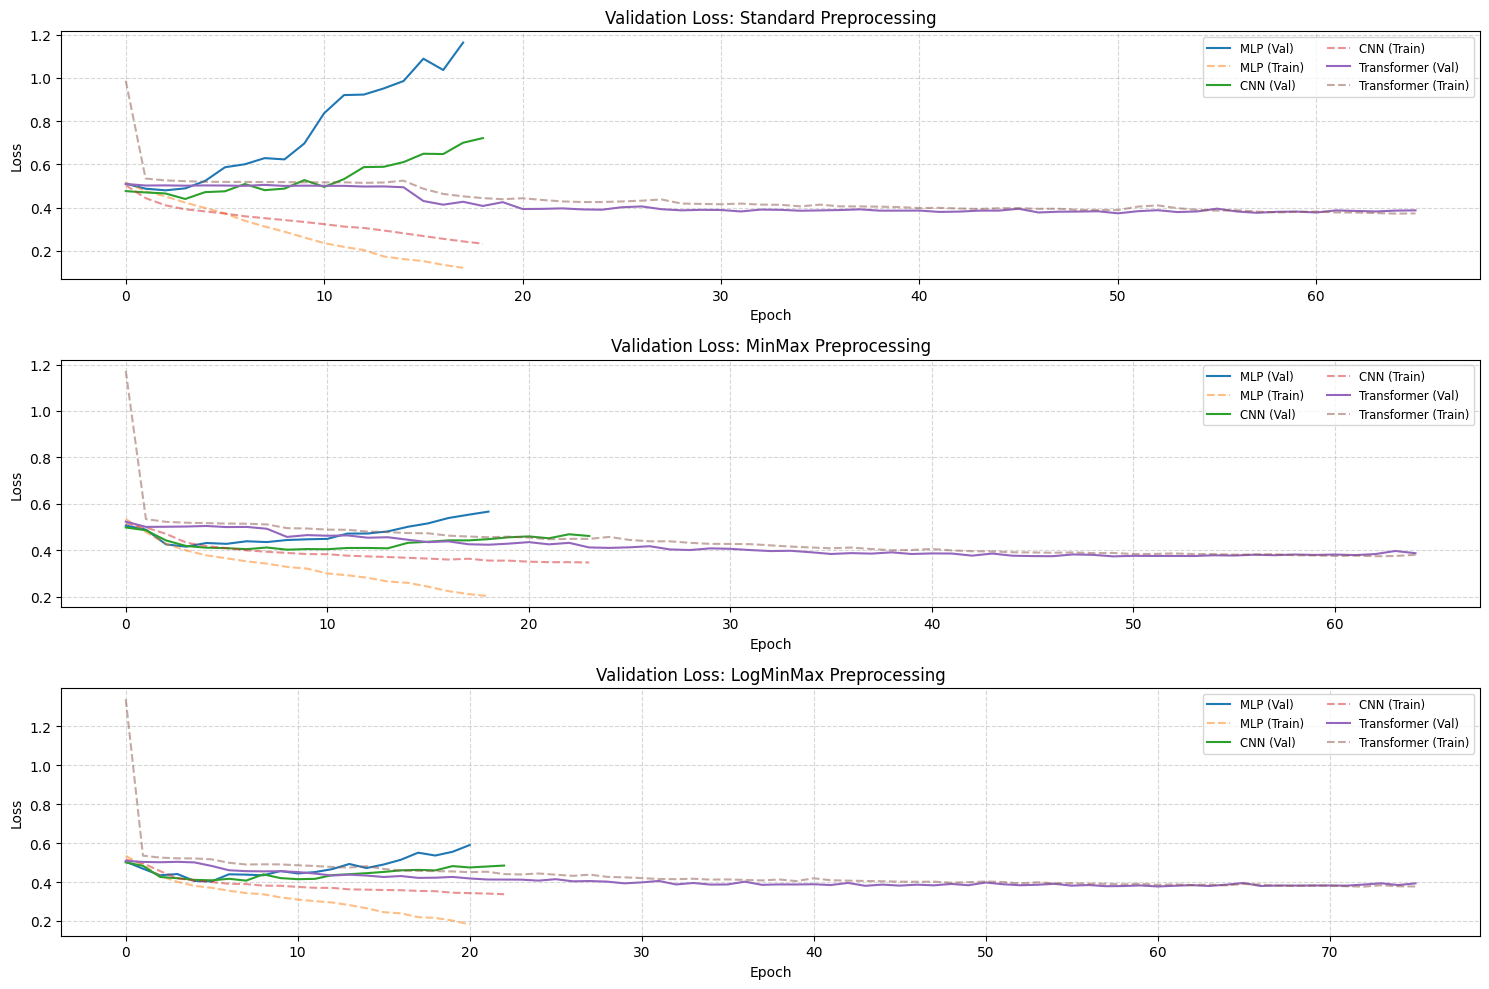

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plot_idx = 1

for prep_name in preprocessing_strategies.keys():
    plt.subplot(len(preprocessing_strategies), 1, plot_idx)

    for arch_name in architectures.keys():
        key = f"{prep_name}_{arch_name}"
        if key in results and results[key]['history'] is not None:
            history = results[key]['history']
            plt.plot(history['val_loss'], label=f"{arch_name} (Val)")
            plt.plot(history['train_loss'], linestyle='--', alpha=0.5, label=f"{arch_name} (Train)")

    plt.title(f"Validation Loss: {prep_name} Preprocessing")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='upper right', ncol=2, fontsize='small')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plot_idx += 1

plt.tight_layout()
plt.show()

# Evaluation & Visualization

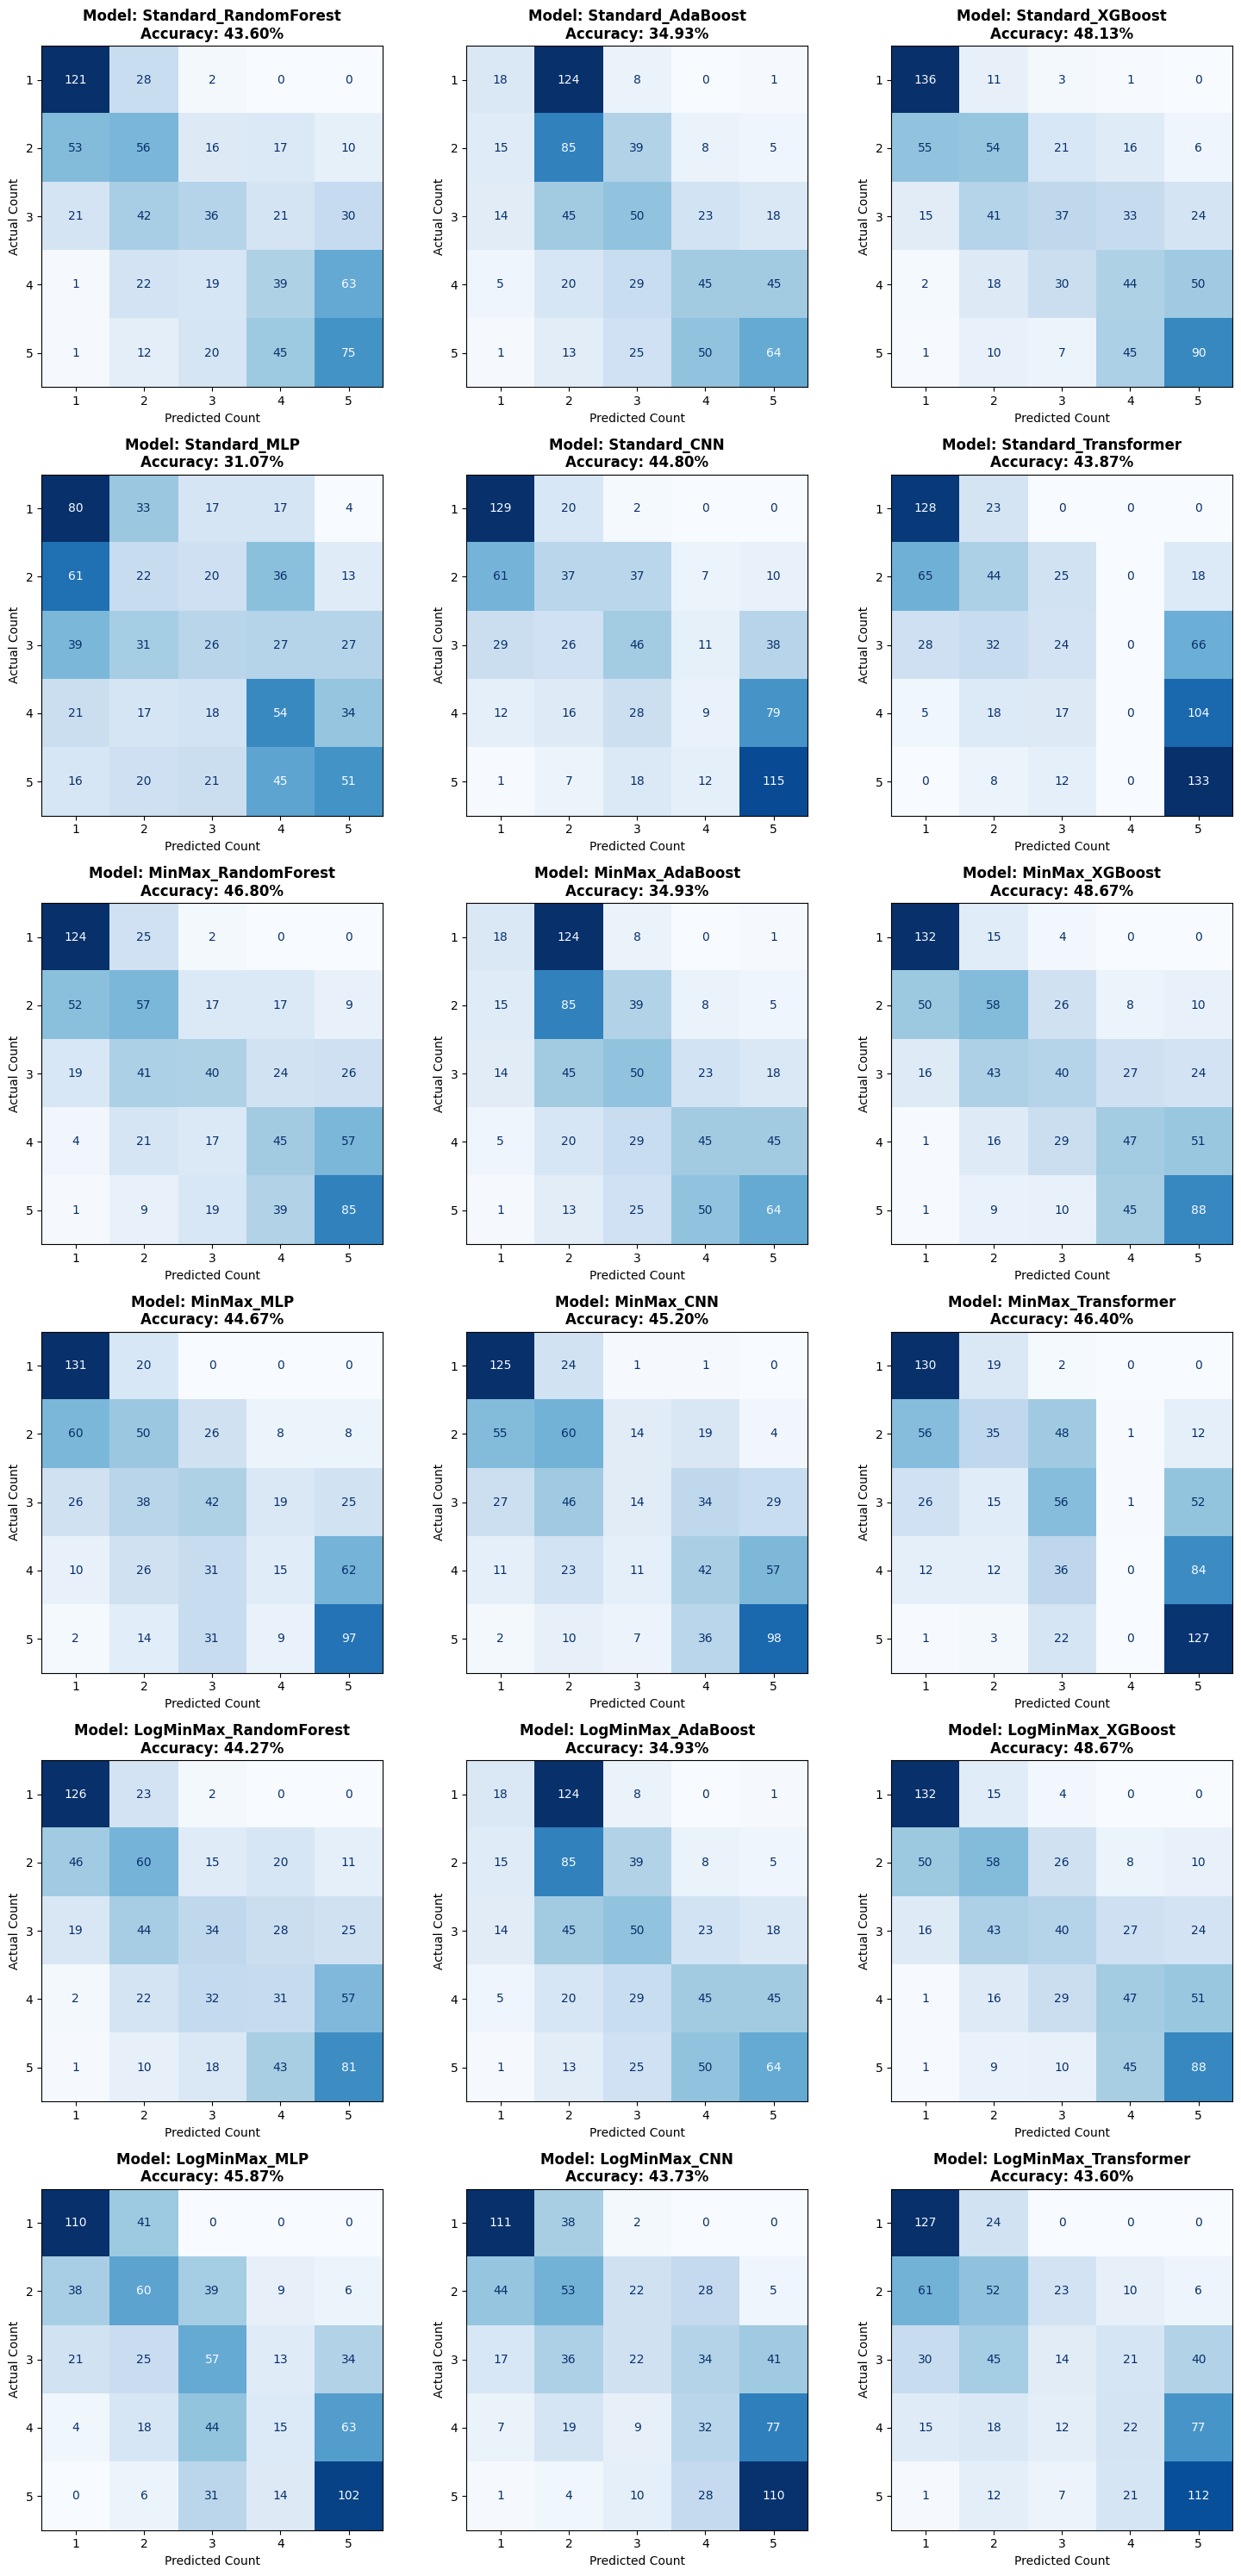

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import math
import matplotlib.pyplot as plt

labels_display = y_labels.columns.tolist()

n_models = len(results)
cols = 3
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, (model_key, res) in enumerate(results.items()):
    ax = axes[i]

    cm = confusion_matrix(res['true'], res['preds'])
    acc = res['accuracy']

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_display)

    disp.plot(cmap='Blues', ax=ax, colorbar=False)

    ax.set_title(f"Model: {model_key}\nAccuracy: {acc:.2%}", fontweight='bold', fontsize=12)
    ax.set_xlabel("Predicted Count")
    ax.set_ylabel("Actual Count")

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

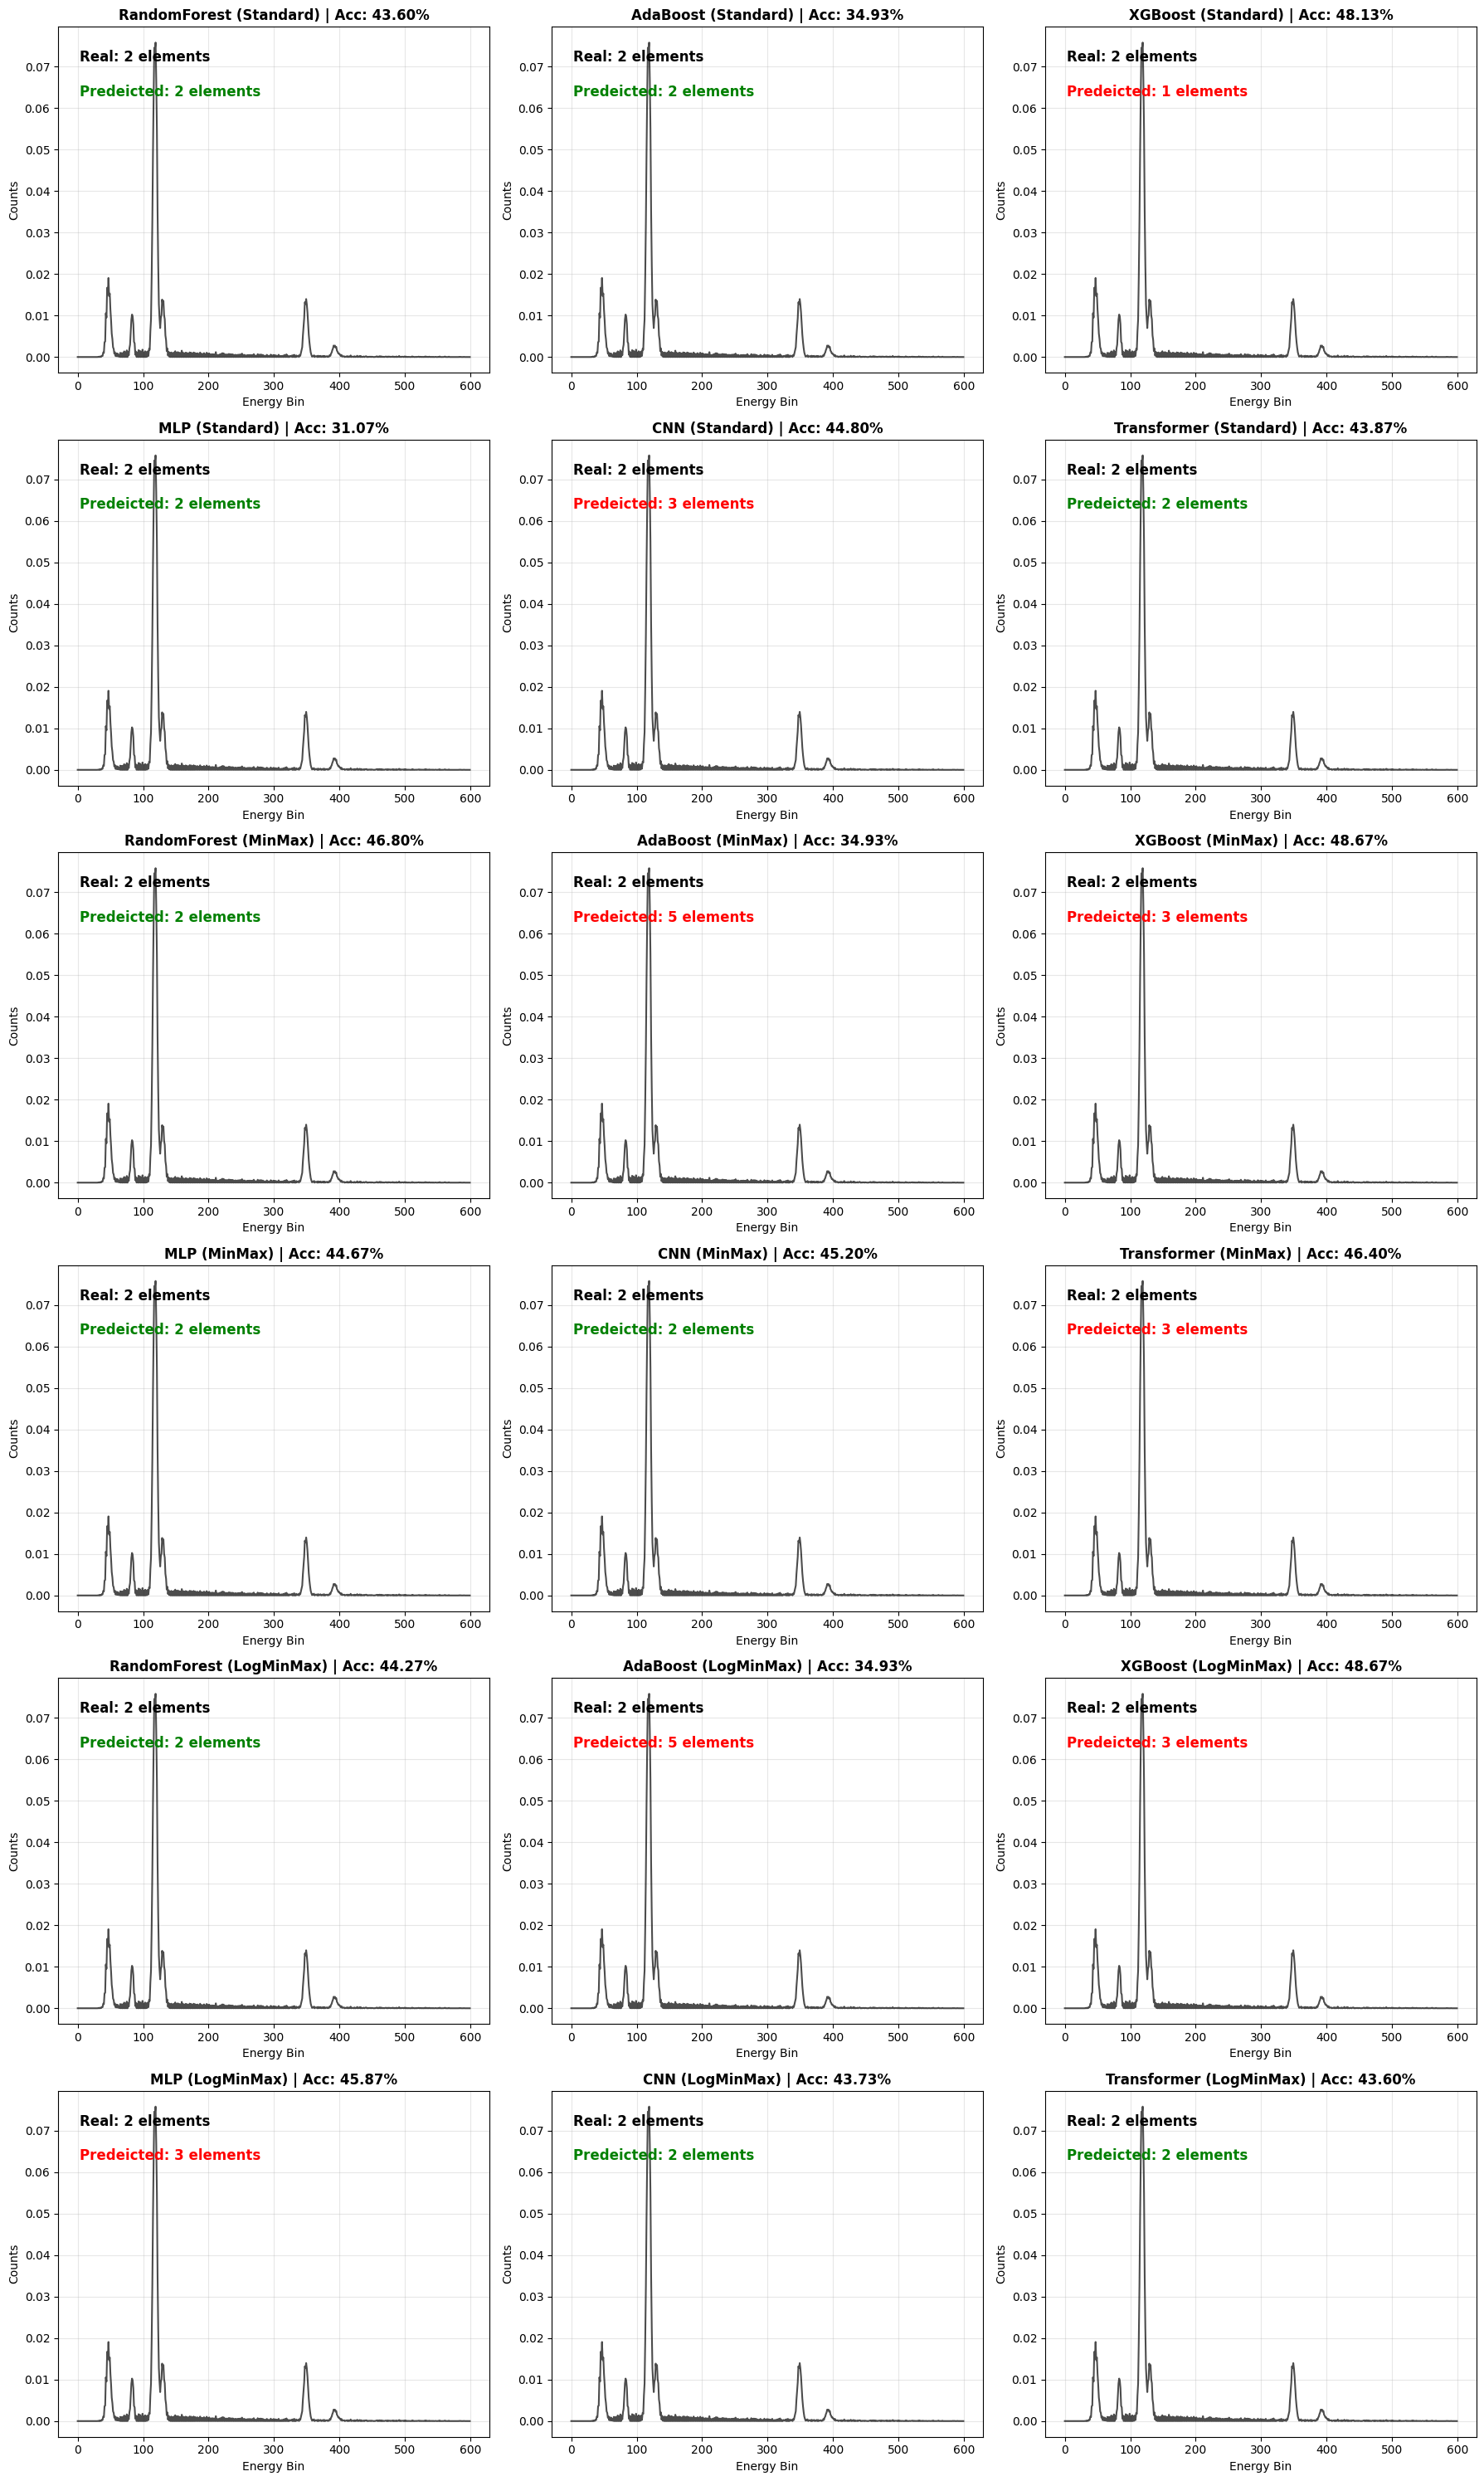

In [24]:
import matplotlib.pyplot as plt
import torch
import math
import numpy as np

sample_idx = np.random.randint(0, len(X_test))

test_spectrum = X_test[sample_idx:sample_idx+1]

true_count = y_test.iloc[sample_idx].idxmax()
true_text = f"Real: {int(true_count)} elements"

n_models = len(trained_models)
cols = 3
rows = math.ceil(n_models / cols)

plt.figure(figsize=(18, 5 * rows))

for i, key in enumerate(trained_models.keys()):
    model, scaler = trained_models[key]
    prep_name, arch_name = key.split('_')[0], key.split('_')[1]
    scaled_input = scaler.transform(test_spectrum)

    if arch_name in ['RandomForest', 'AdaBoost', 'XGBoost']:
        pred_idx = model.predict(scaled_input)[0]
    else:
        model.eval()
        with torch.no_grad():
            device = next(model.parameters()).device
            tensor_input = torch.FloatTensor(scaled_input).to(device)
            pred_idx = np.argmax(model(tensor_input).cpu().numpy(), axis=1)[0]

    pred_count = y_labels.columns[pred_idx]
    pred_text = f"Predeicted: {int(pred_count)} elements"

    if pred_count == true_count:
        text_color = 'green'
    else:
        text_color = 'red'

    plt.subplot(rows, cols, i+1)
    plt.plot(test_spectrum[0], color='black', alpha=0.7)

    acc_val = results[key]['accuracy']
    plt.title(f"{arch_name} ({prep_name}) | Acc: {acc_val:.2%}", fontsize=12, fontweight='bold')

    plt.text(0.05, 0.90, true_text, transform=plt.gca().transAxes, fontsize=12, fontweight='bold')
    plt.text(0.05, 0.80, pred_text, transform=plt.gca().transAxes, fontsize=12, fontweight='bold', color=text_color)

    plt.xlabel("Energy Bin")
    plt.ylabel("Counts")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()